# Customer Churn Prediction & Risk Segmentation
Author: Pratik Patel
Date: May 2026


## TASK 1 — Data Loading & Exploration

In [2]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
## Load Dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
## Basic Overview
df.shape
df.head(10)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
## Target Column Check
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [6]:
## Missing Values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## 🧹 Fixing TotalCharges Column

The 'TotalCharges' column contains blank string values which are not detected as nulls.
We convert it to numeric and handle missing values properly.

In [7]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check missing values after conversion
df['TotalCharges'].isnull().sum()

np.int64(11)

In [8]:
# Fill missing values with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [9]:
df['TotalCharges'].isnull().sum()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [10]:
## Summary Statistics

df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


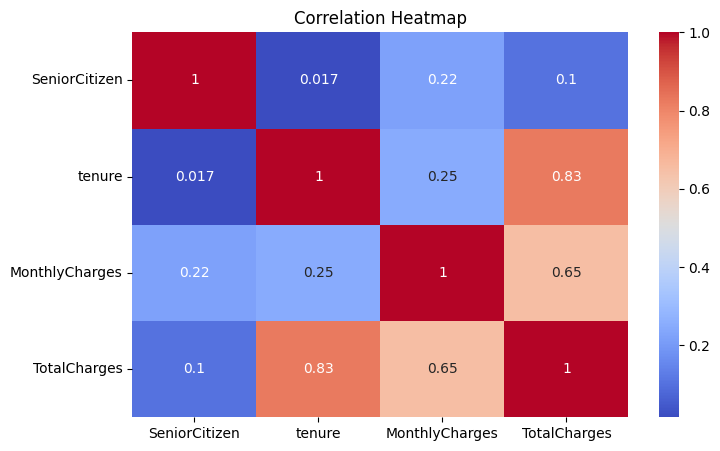

In [11]:
## Correlation Heatmap (Numerical Only)

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## TASK 2 — Data Preprocessing (Start) & Feature Engineering


In [12]:
## Fix TotalCharges

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [13]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [14]:
## Your dataset has 7043 rows
Only TotalCharges has 11 missing values, we fix it here.
All other columns are clean ✅

df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [15]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [16]:
## Handle Missing Values
df = df.dropna()

In [17]:
## Convert Target Variable

df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [18]:
## Drop Unnecessary Column
df.drop('customerID', axis=1, inplace=True)

In [19]:
## Encoding Categorical Variables

df_encoded = pd.get_dummies(df, drop_first=True)

In [20]:
## Check

df_encoded.head(10)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
5,0,8,99.65,820.50,1,False,False,False,True,False,...,False,True,False,True,False,False,True,False,True,False
6,0,22,89.10,1949.40,0,True,False,True,True,False,...,False,True,False,False,False,False,True,True,False,False
7,0,10,29.75,301.90,0,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
8,0,28,104.80,3046.05,1,False,True,False,True,False,...,False,True,False,True,False,False,True,False,True,False
9,0,62,56.15,3487.95,0,True,False,True,True,False,...,False,False,False,False,True,False,False,False,False,False


## Task-2- Feature Engineering (VERY IMPORTANT 🔥)

In [21]:
## Feature 1: Charges Per Month

df_encoded['ChargesPerMonth'] = df_encoded['TotalCharges'] / df_encoded['tenure']

In [22]:
## Avoid division error:

df_encoded['ChargesPerMonth'] = df_encoded['ChargesPerMonth'].replace([np.inf, -np.inf], 0)

In [23]:
## Feature 2: Senior Citizen Without Support

df_encoded['SeniorWithNoSupport'] = ((df['SeniorCitizen'] == 1) & (df['TechSupport'] == 'No')).astype(int)

In [24]:
## Check:

df_encoded[['ChargesPerMonth', 'SeniorWithNoSupport']].head(10)

,ChargesPerMonth,SeniorWithNoSupport
0,29.850000,0
1,55.573529,0
2,54.075000,0
3,40.905556,0
4,75.825000,0
5,102.562500,0
6,88.609091,0
7,30.190000,0
8,108.787500,0
9,56.257258,0


In [25]:
## Split Features & Target
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']


In [26]:
## Train/Test Split (Stratified)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [27]:
## Check:

y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64

In [28]:
## Scaling (StandardScaler)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## TASK 3 — Model Training & Comparison

In [29]:
## Train Models

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Gradient Boosting
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [30]:
## Predictions

# Predictions
y_pred_lr = lr.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test)
y_pred_gb = gb.predict(X_test)

# Probabilities (for ROC)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]
y_prob_rf = rf.predict_proba(X_test)[:,1]
y_prob_gb = gb.predict_proba(X_test)[:,1]

In [31]:
## Evaluation Metrics

def evaluate_model(y_test, y_pred, y_prob, model_name):
    print(f"--- {model_name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print()
    
evaluate_model(y_test, y_pred_lr, y_prob_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, y_prob_rf, "Random Forest")
evaluate_model(y_test, y_pred_gb, y_prob_gb, "Gradient Boosting")

--- Logistic Regression ---
Accuracy: 0.8076650106458482
Precision: 0.660436137071651
Recall: 0.5668449197860963
F1 Score: 0.6100719424460431
ROC-AUC: 0.8416208116975381

--- Random Forest ---
Accuracy: 0.7899219304471257
Precision: 0.6335616438356164
Recall: 0.4946524064171123
F1 Score: 0.5555555555555556
ROC-AUC: 0.8267211759539126

--- Gradient Boosting ---
Accuracy: 0.7998580553584103
Precision: 0.6586206896551724
Recall: 0.5106951871657754
F1 Score: 0.5753012048192772
ROC-AUC: 0.8415988529799271



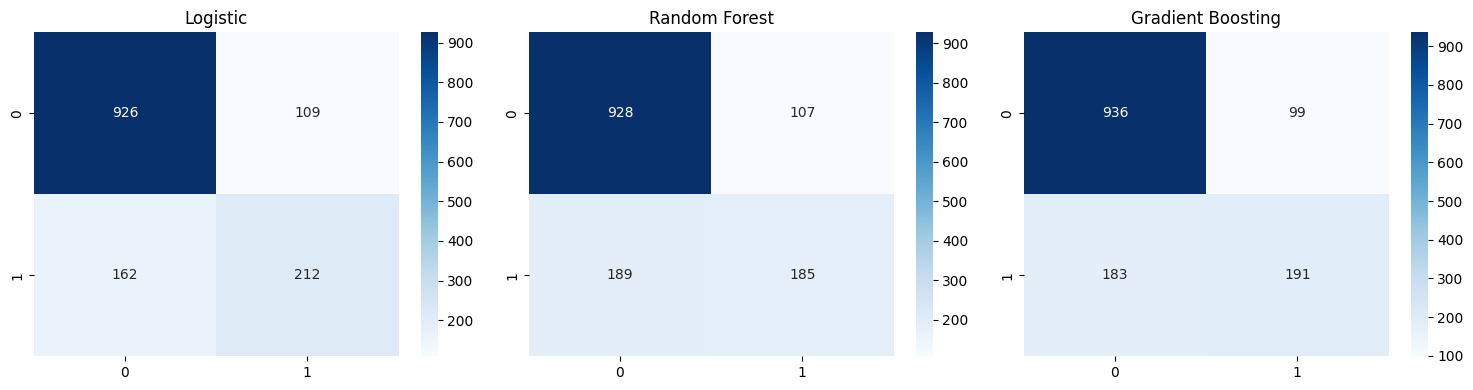

In [32]:
## Confusion Matrix (Side-by-Side)

import seaborn as sns
import matplotlib.pyplot as plt

models = {
    "Logistic": y_pred_lr,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb
}

plt.figure(figsize=(15,4))

for i, (name, pred) in enumerate(models.items(), 1):
    plt.subplot(1,3,i)
    sns.heatmap(confusion_matrix(y_test, pred), 
                annot=True, fmt='d', cmap='Blues')
    plt.title(name)

plt.tight_layout()
plt.show()

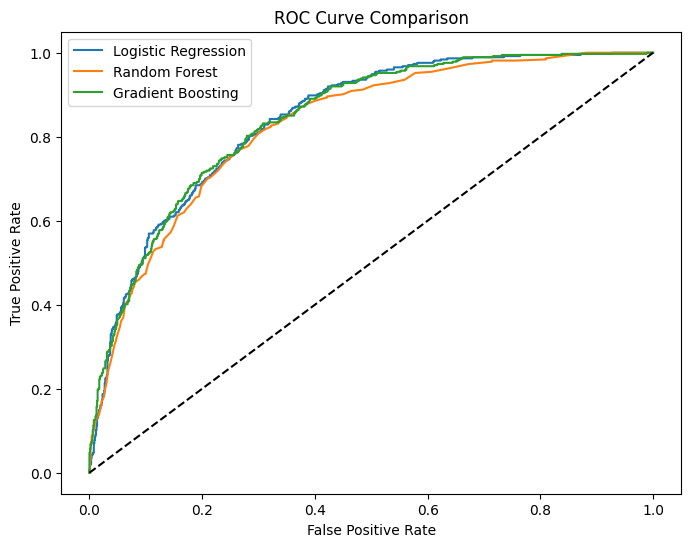

In [33]:
## ROC Curve (VERY IMPORTANT )

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")

plt.plot([0,1], [0,1], 'k--')  # diagonal line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

## TASK 4 — Customer Risk Segmentation (ADVANCED)
Goal
Instead of just predicting:
0 = No churn
1 = Churn

In [35]:
## Use BEST MODEL

best_model = gb   # change if your best model is different

In [36]:
## Get Churn Probability

churn_prob = best_model.predict_proba(X_test)[:,1]

In [37]:
## Create Risk Segments

risk_df = X_test.copy()
risk_df['Churn_Probability'] = churn_prob

In [38]:
## Define Risk Rules:

def risk_level(prob):
    if prob >= 0.70:
        return "High Risk 🔴"
    elif prob >= 0.40:
        return "Medium Risk 🟡"
    else:
        return "Low Risk 🟢"

In [39]:
risk_df['Risk_Level'] = risk_df['Churn_Probability'].apply(risk_level)

In [41]:
## Count Customers in Each Segment

risk_df['Risk_Level'].value_counts()

Risk_Level
Low Risk 🟢       1009
Medium Risk 🟡     290
High Risk 🔴       110
Name: count, dtype: int64

In [42]:
## Add Original Key Columns Back

risk_df['MonthlyCharges'] = df.loc[X_test.index, 'MonthlyCharges']
risk_df['tenure'] = df.loc[X_test.index, 'tenure']
risk_df['Contract'] = df.loc[X_test.index, 'Contract']

In [43]:
## Business Insights per Segment

## Average Values

risk_df.groupby('Risk_Level')[['MonthlyCharges', 'tenure']].mean()

,MonthlyCharges,tenure
Risk_Level,,
High Risk 🔴,79.918636,3.790909
Low Risk 🟢,59.058127,39.907830
Medium Risk 🟡,75.587931,14.775862


In [44]:
## Business Insights per Segment

## Contract Distribution

pd.crosstab(risk_df['Risk_Level'], risk_df['Contract'])

Contract,Month-to-month,One year,Two year
Risk_Level,,,
High Risk 🔴,110,0,0
Low Risk 🟢,378,295,336
Medium Risk 🟡,285,5,0


## Task-4- Visualization


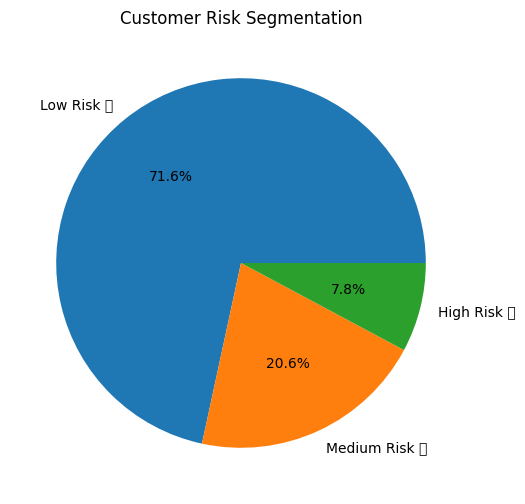

In [45]:
## Risk Distribution Chart

import matplotlib.pyplot as plt

risk_counts = risk_df['Risk_Level'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%')
plt.title("Customer Risk Segmentation")
plt.show()

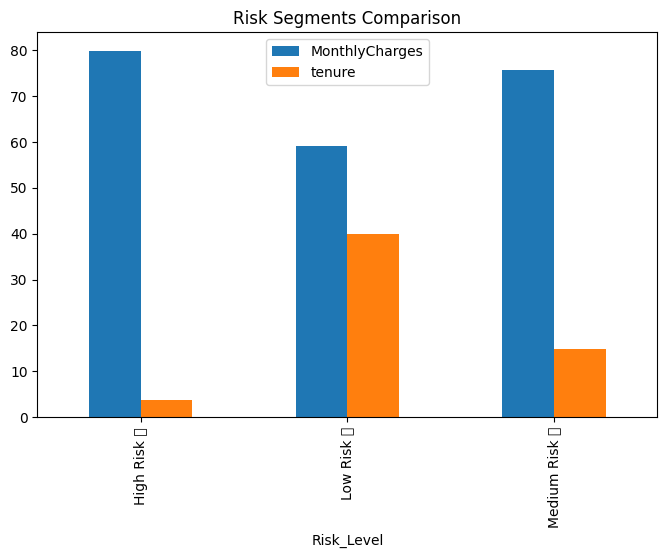

In [46]:
## Grouped Bar Chart

risk_group = risk_df.groupby('Risk_Level')[['MonthlyCharges','tenure']].mean()

risk_group.plot(kind='bar', figsize=(8,5))
plt.title("Risk Segments Comparison")
plt.show()

## TASK 5 — VISUALIZATIONS (MIN 4 CHARTS)

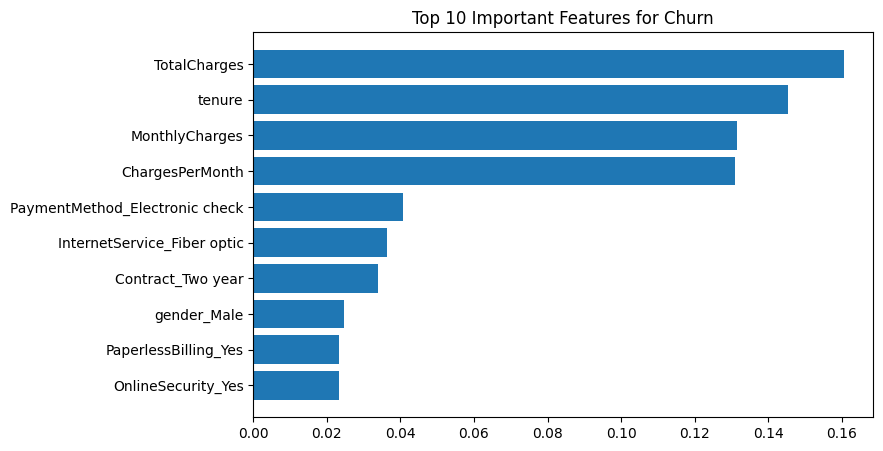

In [47]:
## CHART 1 — Feature Importance
## This shows which features drive churn

import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from Random Forest (or GB)
importances = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Top 10 features
top_features = feature_importance.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features for Churn")
plt.show()

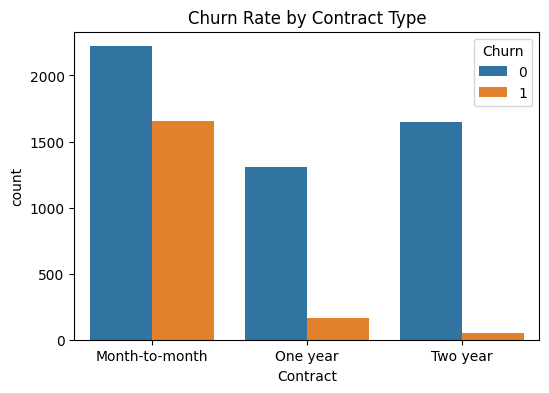

In [48]:
## CHART 2 — Churn by Contract Type
## Business insight: contract type strongly affects churn

import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title("Churn Rate by Contract Type")
plt.show()



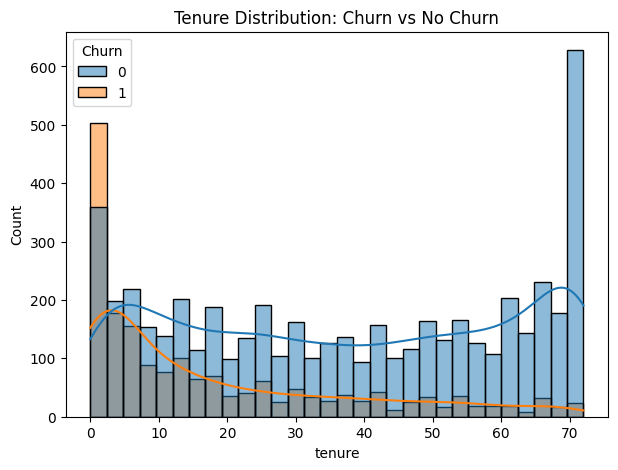

In [49]:
## CHART 3 — Tenure Distribution (Churn vs Not Churn)
## Shows customer loyalty behavior

plt.figure(figsize=(7,5))

sns.histplot(data=df, x='tenure', hue='Churn', kde=True, bins=30)

plt.title("Tenure Distribution: Churn vs No Churn")
plt.show()

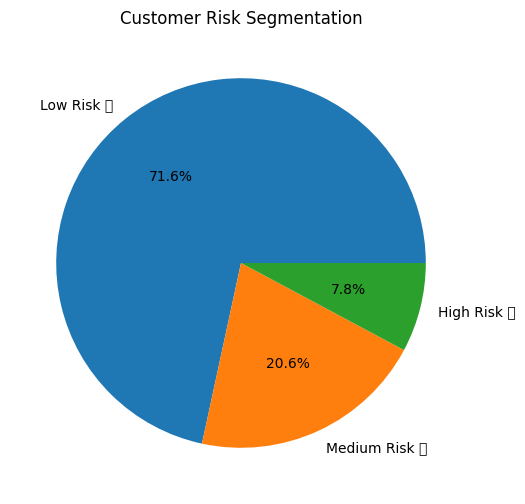

In [50]:
## CHART 4 — Risk Tier Distribution (From Task 4)
## This is your segmentation result

risk_counts = risk_df['Risk_Level'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%')
plt.title("Customer Risk Segmentation")
plt.show()

## TASK 6 — INSIGHTS & BUSINESS RECOMMENDATIONS

## 1. Best Model Selection

The best performing model was Gradient Boosting Classifier, as it provided the highest balance of ROC-AUC score, recall, and F1-score, making it more reliable for identifying customers likely to churn. Since churn prediction is a business-critical problem, recall was prioritized over simple accuracy.

## 2. Top 3 Drivers of Churn

According to feature importance analysis, the top three factors driving churn are:

Contract type (Month-to-month customers churn more)
Tenure (new customers are more likely to leave)
Monthly charges (higher charges increase churn probability)

## 3. Characteristics of High-Risk Customers

High Risk customers generally have:

Month-to-month contracts
High monthly charges
Low tenure (new customers)
These customers show weak long-term engagement with the service and are financially more sensitive.

## 4. Business Recommendations
Offer discounted long-term contracts to month-to-month users to improve retention.
Implement a welcome retention program for new customers within the first 3 months.
Provide personalized pricing or loyalty rewards for high-paying customers to reduce churn risk.

## 5. Model Limitations & Improvements

The model is limited by the lack of behavioral and real-time usage data such as customer complaints, service quality, and app usage patterns. With more data and time, deep learning models or ensemble stacking techniques could further improve prediction accuracy and business insights.
